In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier

In [2]:
df = pd.read_csv('data/clean/df_clean.csv')

In [3]:
X = df.drop("income", axis=1)

y = df["income"].str.strip().map({
    "<=50K": 0,
    ">50K": 1
})

In [4]:
X["gender"] = X["gender"].map({
    "Female": 0,
    "Male": 1
})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(39032, 12)
(9758, 12)


In [6]:
X["gender"] = X["gender"].map({
    "Female": 0,
    "Male": 1
})

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(39032, 12)
(9758, 12)


In [8]:
cat_cols = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "native-country"
]

X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(39032, 50)
(9758, 50)


In [9]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    resultados = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }
    
    return resultados

In [10]:
rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train_encoded, y_train)

resultado_rf_baseline = evaluar_modelo(
    "Random Forest Baseline",
    rf_baseline,
    X_test_encoded,
    y_test
)

resultado_rf_baseline

{'Modelo': 'Random Forest Baseline',
 'Accuracy': 0.842693174830908,
 'Precision': 0.6952705997074597,
 'Recall': 0.610445205479452,
 'F1': 0.6501025757921131,
 'ROC_AUC': 0.8911681775857041}

In [11]:
cv_rf_baseline = cross_val_score(
    rf_baseline,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 medio CV:", cv_rf_baseline.mean())
print("Desviación:", cv_rf_baseline.std())

F1 medio CV: 0.6632453451499165
Desviación: 0.003311387276626015


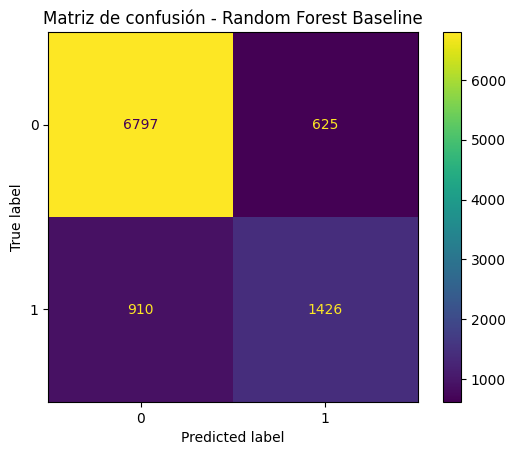

In [12]:
ConfusionMatrixDisplay.from_estimator(
    rf_baseline,
    X_test_encoded,
    y_test
)

plt.title("Matriz de confusión - Random Forest Baseline")
plt.show()

In [13]:
param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=10,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train_encoded, y_train)

print("Mejores parámetros:")
print(rf_search.best_params_)

Mejores parámetros:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


In [14]:
resultado_rf_tuned = evaluar_modelo(
    "Random Forest Tuned",
    rf_search.best_estimator_,
    X_test_encoded,
    y_test
)

resultado_rf_tuned

{'Modelo': 'Random Forest Tuned',
 'Accuracy': 0.8624718179954909,
 'Precision': 0.7593945720250522,
 'Recall': 0.6228595890410958,
 'F1': 0.6843838193791157,
 'ROC_AUC': 0.9152823208399316}

In [15]:
lgbm_baseline = LGBMClassifier(random_state=42, verbose=-1)

lgbm_baseline.fit(X_train_encoded, y_train)

resultado_lgbm_baseline = evaluar_modelo(
    "LightGBM Baseline",
    lgbm_baseline,
    X_test_encoded,
    y_test
)

resultado_lgbm_baseline

{'Modelo': 'LightGBM Baseline',
 'Accuracy': 0.8684156589465054,
 'Precision': 0.7689161554192229,
 'Recall': 0.6438356164383562,
 'F1': 0.700838769804287,
 'ROC_AUC': 0.9253523459042535}

In [16]:
cv_lgbm_baseline = cross_val_score(
    lgbm_baseline,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 medio CV:", cv_lgbm_baseline.mean())
print("Desviación:", cv_lgbm_baseline.std())

F1 medio CV: 0.7140617672539727
Desviación: 0.005754890330244776


In [17]:
param_lgbm = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_lgbm,
    n_iter=10,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train_encoded, y_train)

print("Mejores parámetros:")
print(lgbm_search.best_params_)

Mejores parámetros:
{'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [18]:
resultado_lgbm_tuned = evaluar_modelo(
    "LightGBM Tuned",
    lgbm_search.best_estimator_,
    X_test_encoded,
    y_test
)

resultado_lgbm_tuned

{'Modelo': 'LightGBM Tuned',
 'Accuracy': 0.8698503791760607,
 'Precision': 0.7730532786885246,
 'Recall': 0.6459760273972602,
 'F1': 0.7038246268656716,
 'ROC_AUC': 0.9259963148710055}

In [19]:
resultados = pd.DataFrame([
    resultado_rf_baseline,
    resultado_rf_tuned,
    resultado_lgbm_baseline,
    resultado_lgbm_tuned
])

resultados.sort_values(by="F1", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
3,LightGBM Tuned,0.869850,0.773053,0.645976,0.703825,0.925996
2,LightGBM Baseline,0.868416,0.768916,0.643836,0.700839,0.925352
1,Random Forest Tuned,0.862472,0.759395,0.622860,0.684384,0.915282
0,Random Forest Baseline,0.842693,0.695271,0.610445,0.650103,0.891168


## Conclusión final de modelos

Tras entrenar y comparar los cuatro modelos, se observa que el modelo con mejor rendimiento general es **LightGBM Tuned**.

Este modelo obtiene la mayor accuracy, con un valor de 0,8698, y también el mejor F1-score, con 0,7042. Además, alcanza el mejor ROC-AUC, con 0,9260, lo que indica que es el modelo con mayor capacidad para separar correctamente las personas con ingresos superiores a 50K de las personas con ingresos menores o iguales a 50K.

Comparando LightGBM Baseline con LightGBM Tuned, se observa que el fine tuning mejora ligeramente los resultados. La mejora no es muy grande, pero sí permite obtener el mejor resultado global del trabajo. En cambio, en Random Forest la mejora del fine tuning es más clara, pasando de un F1-score de 0,6502 a 0,6823, aunque sigue quedando por debajo de LightGBM.

También se puede ver que LightGBM tiene mejores resultados que Random Forest en todas las métricas principales. Esto indica que, para este problema, el modelo basado en boosting se adapta mejor a los datos que el modelo basado en árboles aleatorios.

Como la variable objetivo está desbalanceada, no se ha elegido el modelo únicamente por la accuracy. También se han tenido en cuenta precision, recall, F1-score y ROC-AUC. En este caso, **LightGBM Tuned** es el modelo seleccionado porque consigue el mejor equilibrio entre precisión, capacidad de detección de la clase positiva y rendimiento general.